# AFRO-PRODUCTIONS ANALYSIS

Authors: 
- Angela Masaki
- Joy Nyuguto
- David Theuri
- Joel Muoki
- Felista Mwangi

## Overview

This notebook presents an exploratory data analysis (EDA) aimed at informing the launch of a new film studio. It examines box office performance, production budgets, and genre trends across multiple data sources to identify the key factors that differentiate high-performing films from less successful ones.

# Business Understanding

### Key Stakeholder

The Head of the New Movie Studio (Afro Productions)

### Business Problem

Afro Productions aims to enter the original film production industry without prior experience or historical performance data to guide decision-making. This creates significant uncertainty around key strategic choices, including which genres to invest in, how much to allocate for production budgets, when to release films, and which market segments to target.

Without data-driven insights, the company risks investing heavily in projects that may fail to generate sufficient returns, potentially leading to substantial financial losses. A single underperforming film could jeopardize the sustainability of the business. Therefore, the core problem is determining how Afro Productions can minimize risk and maximize profitability by identifying the factors that drive successful movie performance before making its initial investment decisions.


### Key Business Questions

Q1.What film genres give the best return on investment?

Q2.What production budget range maximizes profiatability?

Q3.Which release month generates the highest box office gross?

Q4.Should our studio prioritize domestic or international markets?

Q5.Which studios should we model ourselves after?



## Data Understanding

This project utilizes three datasets sourced from different movie analytics platforms. Each dataset provides a unique perspective on movie performance, including financial outcomes, audience reception, and production details.

- **Box Office Mojo:**

    This dataset focuses on box office performance and includes variables such as title, studio, domestic gross, foreign gross, and release year. It is primarily used to **analyze revenue trends across films**.

- **TheMovieDB (TMDb):**

    This dataset provides information related to audience engagement and movie characteristics. It includes features such as genre IDs, original language, popularity, release date, vote average, and vote count. This data helps **evaluate how audiences perceive and interact with movies**.

- **The Numbers:**

    This dataset **emphasizes production and financial efficiency**. It contains variables such as production budget, domestic gross, and worldwide gross, which are useful for assessing profitability and return on investment.

Together, these datasets enable a comprehensive analysis of movie success from multiple dimensions, including revenue generation, audience reception, and production investment.



In [11]:
# Import important libraries

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [12]:
# Load the datasets
bom = pd.read_csv('../zippedData/bom.movie_gross.csv.gz')
tmdb = pd.read_csv('../zippedData/tmdb.movies.csv.gz')
tn = pd.read_csv('../zippedData/tn.movie_budgets.csv.gz')

In [13]:

# Data sets shape(row,columns)
print(f'tn shape:{tn.shape}')
print(f'tmdb shape:{tmdb.shape}')
print(f'bom shape:{bom.shape}')


#Find column names of each dataset
print(f'tn columns:{list(tn.columns)}')
print(f'tmdb columns:{list(tmdb.columns)}')
print(f'bom columns:{list(bom.columns)}')

tn shape:(5782, 6)
tmdb shape:(26517, 10)
bom shape:(3387, 5)
tn columns:['id', 'release_date', 'movie', 'production_budget', 'domestic_gross', 'worldwide_gross']
tmdb columns:['Unnamed: 0', 'genre_ids', 'id', 'original_language', 'original_title', 'popularity', 'release_date', 'title', 'vote_average', 'vote_count']
bom columns:['title', 'studio', 'domestic_gross', 'foreign_gross', 'year']


## Data Preparation

Here we turn raw, messy, chaotic data into structured, trustworthy and meaningful data.

---


In [14]:
# Data preview
print("The Numbers (tn):")
display(tn.head())

print("The Movie DB (tmdb):")
display(tmdb.head())

print("Box Office Mojo (bom):")
display(bom.head()) 

The Numbers (tn):


,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


The Movie DB (tmdb):


,Unnamed: 0,genre_ids,id,original_language,original_title,popularity,release_date,title,vote_average,vote_count
0,0,"[12, 14, 10751]",12444,en,Harry Potter and the Deathly Hallows: Part 1,33.533,2010-11-19,Harry Potter and the Deathly Hallows: Part 1,7.7,10788
1,1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,2010-03-26,How to Train Your Dragon,7.7,7610
2,2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368
3,3,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174
4,4,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186


Box Office Mojo (bom):


,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


### Cleaning The Number CSV

---


In [15]:
#  Rename 'id' to  'rank' (not a true unique ID)- instead it represents rank according to production budget rank 
tn = tn.rename(columns={'id': 'rank'})

#Removing commas and $ signs from money columns then converting to numbers
for col in ['production_budget', 'domestic_gross', 'worldwide_gross']:
       tn[col] = tn[col].str.replace('$', '', regex=False)
       tn[col] = tn[col].str.replace(',', '', regex=False)
       tn[col] = tn[col].astype(float)   


#Repacing 0 values in columns with Nan
for col in ['production_budget', 'domestic_gross', 'worldwide_gross']:
    tn[col] = tn[col].replace(0, np.nan)

# Dropping rows with missing financial data values 
tn = tn.dropna(subset=['production_budget', 'domestic_gross', 'worldwide_gross'])

#Parsing release date
tn['release_date'] = pd.to_datetime(tn['release_date'])

# Extracting release year and months into their own columns
tn['year'] = tn['release_date'].dt.year
tn['month'] = tn['release_date'].dt.month

print("tn after cleaning")
print(tn.dtypes)
print()
print(tn.isnull().sum())
print()
print(tn.head())

tn after cleaning
rank                          int64
release_date         datetime64[ns]
movie                        object
production_budget           float64
domestic_gross              float64
worldwide_gross             float64
year                          int32
month                         int32
dtype: object

rank                 0
release_date         0
movie                0
production_budget    0
domestic_gross       0
worldwide_gross      0
year                 0
month                0
dtype: int64

   rank release_date                                        movie  \
0     1   2009-12-18                                       Avatar   
1     2   2011-05-20  Pirates of the Caribbean: On Stranger Tides   
2     3   2019-06-07                                 Dark Phoenix   
3     4   2015-05-01                      Avengers: Age of Ultron   
4     5   2017-12-15            Star Wars Ep. VIII: The Last Jedi   

   production_budget  domestic_gross  worldwide_gross  year  month

The process taken above: 
- Renamed id to rank since the column represents budget ranking, not a unique identifier

- Stripped $ signs and commas from the three money columns (production_budget, domestic_gross, worldwide_gross) and converted them from strings to floats

- Replaced $0 entries with NaN since a film with zero budget or zero gross is likely a data entry error

- Dropped rows missing any of the three financial columns since these are essential for our analysis
- Parsed release_date from string to datetime and extracted year and month as separate columns

---

### Cleaning Movie DB 



In [16]:
# Dropping the unnamed index column 
tmdb = tmdb.drop(columns=['Unnamed: 0'])

# Parsing release_date from string to datetime
tmdb['release_date'] = pd.to_datetime(tmdb['release_date'])

# Extracting year and month
tmdb['year'] = tmdb['release_date'].dt.year
tmdb['month'] = tmdb['release_date'].dt.month

# Dropping  rows where genre_ids is empty 
tmdb = tmdb[tmdb['genre_ids'] != '[]']

# Convert genre_ids from a string like "[12, 14]" to an actual Python list
import ast
tmdb['genre_ids'] = tmdb['genre_ids'].apply(ast.literal_eval)

# Drop films with fewer than 10 votes since they are unreliable
tmdb = tmdb[tmdb['vote_count'] >= 10]

# Genre ID to name dictionary (official TMDB genre IDs)
GENRE_MAP = {
    28: 'Action',    12: 'Adventure',  16: 'Animation',   35: 'Comedy',
    80: 'Crime',     99: 'Documentary',18: 'Drama',     10751: 'Family',
    14: 'Fantasy',   36: 'History',    27: 'Horror',    10402: 'Music',
  9648: 'Mystery', 10749: 'Romance',  878: 'Sci-Fi',   10770: 'TV Movie',
    53: 'Thriller', 10752: 'War',      37: 'Western'
}

# Getting  the first genre from each list and mappin it to a name
tmdb['primary_genre'] = tmdb['genre_ids'].apply(lambda x: GENRE_MAP.get(x[0], 'Unknown'))

# Dropping rows where genre couldn't be decoded
tmdb = tmdb[tmdb['primary_genre'] != 'Unknown']


print("tmdb after cleaning")
print(f"Rows remaining: {len(tmdb)}")
print(tmdb.dtypes)
print()
print(tmdb.isnull().sum())
print()
print(tmdb.head())

tmdb after cleaning
Rows remaining: 10348
genre_ids                    object
id                            int64
original_language            object
original_title               object
popularity                  float64
release_date         datetime64[ns]
title                        object
vote_average                float64
vote_count                    int64
year                          int32
month                         int32
primary_genre                object
dtype: object

genre_ids            0
id                   0
original_language    0
original_title       0
popularity           0
release_date         0
title                0
vote_average         0
vote_count           0
year                 0
month                0
primary_genre        0
dtype: int64

             genre_ids     id original_language  \
0      [12, 14, 10751]  12444                en   
1  [14, 12, 16, 10751]  10191                en   
2        [12, 28, 878]  10138                en   
3      [16, 35, 1

The process taken above include:

- Dropped the unnamed index column which added no value
- Parsed release_date from string to datetime and extracted year and month
- Removed rows with empty genre lists ([]) since genre is central to our analysis
- Converted genre_ids from a string representation into actual Python lists
- Removed films with fewer than 10 votes since ratings based on very few reviews are unreliable
- Decoded genre IDs into readable names (e.g. 28 to Action) using the official TMDB genre mapping and stored the first listed genre as primary_genre

---

### Cleaning Box Office Mojo


In [17]:
# Drop rows with missing studio values
bom = bom.dropna(subset=['studio'])

# Convert foreign_gross from string to float
bom['foreign_gross'] = pd.to_numeric(bom['foreign_gross'], errors='coerce')

# Computing total gross 
bom['total_gross'] = bom['domestic_gross'].fillna(0) + bom['foreign_gross'].fillna(0)

# Dropping  rows with missing  BOTH domestic and foreign gross values
bom = bom.dropna(subset=['domestic_gross', 'foreign_gross'], how='all')

print("bom after cleaning")
print(f"Rows remaining: {len(bom)}")
print(bom.dtypes)
print()
print(bom.isnull().sum())
print()
print()
print(bom.head())

bom after cleaning
Rows remaining: 3382
title              object
studio             object
domestic_gross    float64
foreign_gross     float64
year                int64
total_gross       float64
dtype: object

title                0
studio               0
domestic_gross      26
foreign_gross     1354
year                 0
total_gross          0
dtype: int64


                                         title studio  domestic_gross  \
0                                  Toy Story 3     BV     415000000.0   
1                   Alice in Wonderland (2010)     BV     334200000.0   
2  Harry Potter and the Deathly Hallows Part 1     WB     296000000.0   
3                                    Inception     WB     292600000.0   
4                          Shrek Forever After   P/DW     238700000.0   

   foreign_gross  year   total_gross  
0    652000000.0  2010  1.067000e+09  
1    691300000.0  2010  1.025500e+09  
2    664300000.0  2010  9.603000e+08  
3    535700000.0  2010  8.283000e+08  
4 

The process taken above include:

- Dropped 5 rows with missing studio information
- Converted foreign_gross from string to float using pd.to_numeric
- Created a total_gross column by summing domestic and foreign gross
- Dropped rows where both domestic and foreign gross were missing and rows with at least one value were kept

## Data Visualization 

### Q1. What film genres give the best return on investment(ROI)?

In [18]:
# Merging tn and tmdb on movie title
# Converting all titles to lowercase and removing extra spaces for proper matching
tn['title_key']  = tn['movie'].str.lower().str.strip()
tmdb['title_key'] = tmdb['title'].str.lower().str.strip()

#  Avoiding duplicates after merging(dropping possible duplicates) 
tmdb_dup = tmdb.drop_duplicates(subset='title_key')[['title_key', 'primary_genre']]

# Using inner join to merge 
tn_genre = tn.merge(tmdb_dup, on='title_key', how='inner')

print(f"Films matched to a genre: {len(tn_genre)}")

#Computing profit and ROI 
tn_genre['profit'] = tn_genre['worldwide_gross'] - tn_genre['production_budget']
tn_genre['roi']    = (tn_genre['profit'] / tn_genre['production_budget']) * 100

#  Median ROI per genre 
genre_roi = (tn_genre.groupby('primary_genre')['roi']
             .median()
             .sort_values(ascending=False).head(10)
             .reset_index())
genre_roi.columns = ['genre', 'median_roi']
print(genre_roi)

Films matched to a genre: 1642
       genre  median_roi
0   TV Movie  344.766110
1     Horror  307.492300
2    Mystery  217.238065
3  Animation  209.097806
4     Family  199.204940
5    History  156.895104
6    Romance  147.245329
7     Action  146.361160
8     Sci-Fi  138.493409
9  Adventure  134.790394


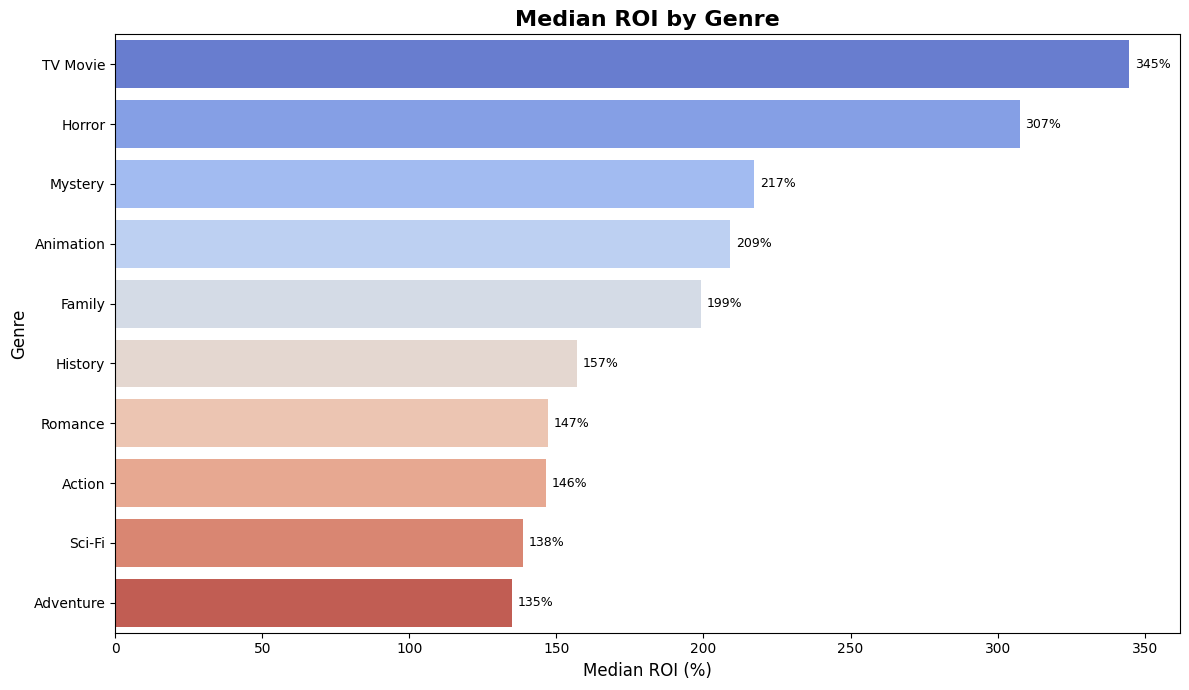

In [21]:

#Plotting bar plot
plt.figure(figsize=(12, 7))

ax = sns.barplot(data=genre_roi, x='median_roi', y='genre', palette='coolwarm')

#Adding values to each bar
for i, value in enumerate(genre_roi['median_roi']):
    plt.text(value + 2, i, f'{value:.0f}%', va='center', fontsize=9)

plt.title('Median ROI by Genre', fontsize=16, fontweight='bold')
plt.xlabel('Median ROI (%)', fontsize=12)
plt.ylabel('Genre', fontsize=12)

plt.tight_layout()
plt.savefig('../images/q1_genre_roi.png')
plt.show()

### Conclusion

The analysis reveals clear differences in profitability across film genres, with lower-budget genres consistently delivering stronger returns on investment. Horror, Mystery, and Animation stand out as the most reliable performers, achieving high median ROI due to their ability to generate substantial revenue relative to their modest production costs. This highlights a key industry pattern: profitability is not solely driven by high box office earnings, but by efficient cost management.

While TV Movie records the highest median ROI overall, it is not directly comparable to theatrical releases and is therefore excluded from strategic recommendations. Among theatrical genres, the findings suggest that investing in cost-efficient productions offers a more sustainable and less risky path to profitability than high-budget genres such as Action, Sci-Fi, and Adventure, which show comparatively lower returns despite their scale.

Overall, the results emphasize the importance of aligning production budgets with realistic revenue expectations, suggesting that studios can maximize returns by prioritizing genres that balance audience appeal with controlled production costs.

---

### Q2.What production budget range maximizes profitability?

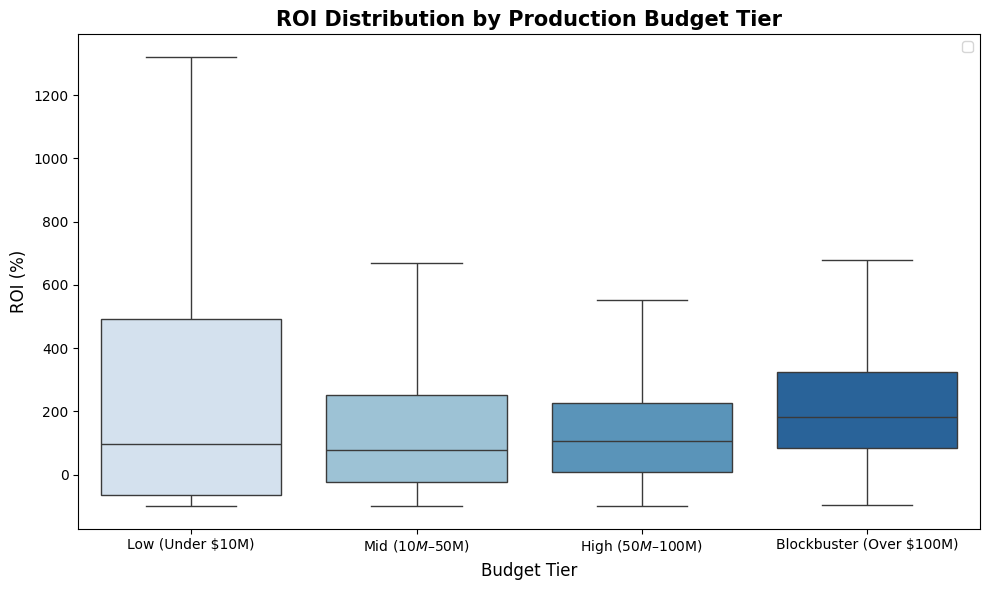

In [22]:
# Computing profit and ROI on tn 

# Adding a profit column: worldwide gross minus production budget
tn['profit'] = tn['worldwide_gross'] - tn['production_budget']

# Adding an roi column: profit divided by budget multiplied by 100
tn['roi']    = (tn['profit'] / tn['production_budget']) * 100

# Grouping films into budget tiers so to compare performance across different spending levels
# Blockbuster-a film with a very large production budget
budget_bins   = [0, 10e6, 50e6, 100e6, float('inf')]
budget_labels = ['Low (Under $10M)', 'Mid ($10M–$50M)', 'High ($50M–$100M)', 'Blockbuster (Over $100M)']

# pd.cut divides the data into buckets based on the ranges we defined in budget_bins
# each film gets labelled with the tier it falls into
tn['budget_tier'] = pd.cut(tn['production_budget'], bins=budget_bins, labels=budget_labels)

# Plot — box plot showing ROI spread within each budget tier
plt.figure(figsize=(10, 6))

sns.boxplot(data=tn, x='budget_tier',y='roi',palette='Blues',order=budget_labels,showfliers=False)

plt.title('ROI Distribution by Production Budget Tier', fontsize=15, fontweight='bold')
plt.xlabel('Budget Tier', fontsize=12)
plt.ylabel('ROI (%)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('../images/q2_distribution_production_tier.png')
plt.show()

### Conclusion

The distribution of ROI across production budget tiers reveals a clear trade-off between risk and return. Low-budget films (under $10M) exhibit the highest variability, with the potential for exceptionally high returns but also a significant risk of losses. This wide spread suggests that while some low-budget films achieve outstanding success, many fail to generate consistent profits.

Mid- and high-budget films show more moderate and relatively stable ROI distributions, indicating a balance between risk and return. These tiers benefit from better production quality and marketing reach, but their higher costs limit the extent of profitability compared to the most successful low-budget films.

Blockbuster films (over $100M), while delivering the highest median ROI among the tiers, demonstrate more consistency and predictability in returns. This suggests that large-scale productions, supported by strong marketing and established audiences, are less volatile but offer fewer extreme profit outcomes compared to low-budget films.

Overall, the findings highlight that lower-budget films present high-risk, high-reward opportunities, whereas higher-budget films provide more stable but comparatively controlled returns. This underscores the importance of aligning investment strategies with an organization’s risk tolerance and financial objectives.

---

### Q3. Which release month generates the highest box office gross?

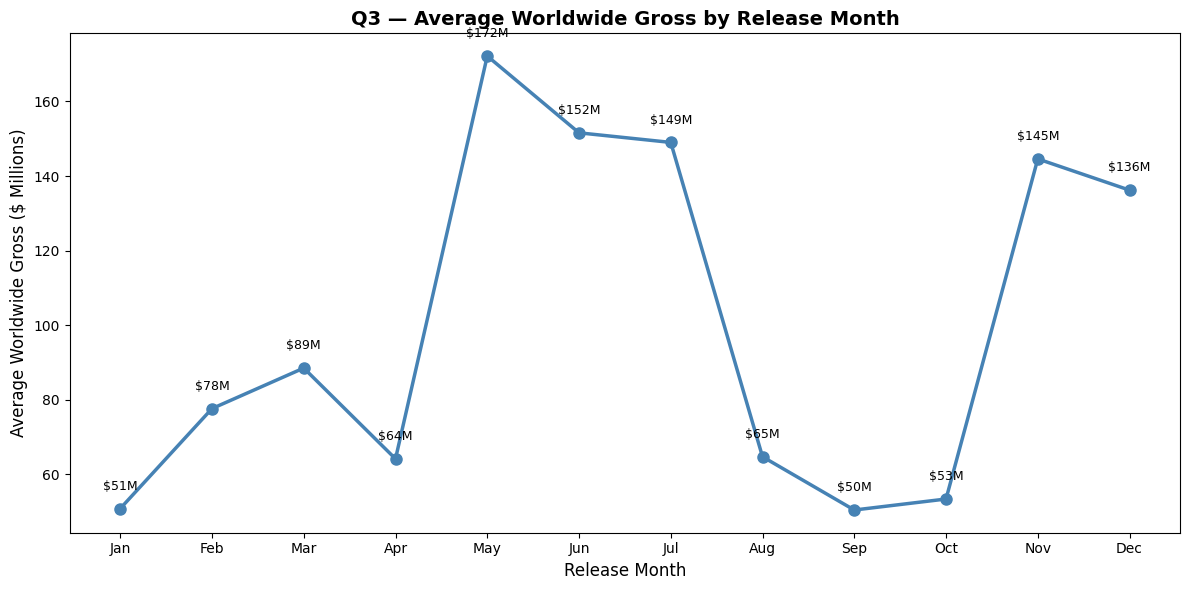

In [23]:
# Calculating average worldwide gross for each month
monthly_gross = tn.groupby('month')['worldwide_gross'].mean().reset_index()

# Mapping month numbers to month names 
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

monthly_gross['month_name'] = monthly_gross['month'].map(month_names)

#line plot showing how average gross changes across the year
plt.figure(figsize=(12, 6))

plt.plot(monthly_gross['month_name'],monthly_gross['worldwide_gross'] / 1e6, marker='o',linewidth=2.5,color='steelblue',markersize=8)

# Adding labels for values
for i, row in monthly_gross.iterrows():
    plt.text(i,row['worldwide_gross'] / 1e6 + 5,f"${row['worldwide_gross']/1e6:.0f}M", ha='center',fontsize=9
    )

plt.title('Q3 — Average Worldwide Gross by Release Month', fontsize=14, fontweight='bold')
plt.xlabel('Release Month', fontsize=12)
plt.ylabel('Average Worldwide Gross ($ Millions)', fontsize=12)

plt.tight_layout()
plt.savefig('../images/q3_gross_release_month.png')
plt.show()


## Conclusion

The analysis of average worldwide gross by release month reveals a strong seasonal pattern in movie performance. Films released in May, June, and July generate the highest revenues, with May standing out as the peak month. This aligns with the traditional summer blockbuster window, where studios capitalize on larger audiences, holidays, and increased theater attendance.

A secondary peak is observed in November and December, suggesting that the holiday season also provides a highly profitable release window, likely driven by family audiences and festive demand.

In contrast, the early months of the year (January to April) and the late summer/early fall period (August to October) show significantly lower average grosses. These periods appear less favorable for major releases, possibly due to lower audience turnout and fewer high-profile films.

Overall, the findings highlight the critical role of release timing in a film’s financial success. Strategically scheduling releases during peak seasons—particularly summer and the end-of-year holidays—can significantly enhance box office performance, while off-peak months may pose higher risks for revenue generation.

---

### Q4. Should our studio prioritize domestic or international markets?

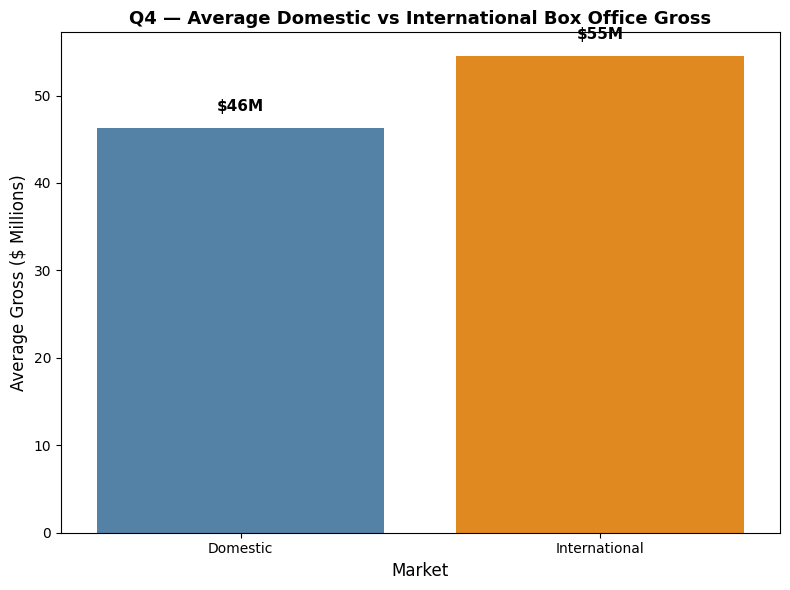

In [24]:
# Calculating international gross
tn['international_gross'] = tn['worldwide_gross'] - tn['domestic_gross']

# Calculate the average gross for each market
avg_domestic       = tn['domestic_gross'].mean() / 1e6
avg_international  = tn['international_gross'].mean() / 1e6

# Using asmall dataframe for easy plotting
market_df = pd.DataFrame({
    'Market'      : ['Domestic', 'International'],
    'Average Gross': [avg_domestic, avg_international]
})

# bar plot
plt.figure(figsize=(8, 6))

ax = sns.barplot(data=market_df,x='Market',y='Average Gross',palette=['steelblue', 'darkorange']
)

# Adding  labels to bar values
for i, value in enumerate(market_df['Average Gross']):
    plt.text(i, value + 2, f'${value:.0f}M', ha='center', fontsize=11, fontweight='bold')

plt.title('Q4 — Average Domestic vs International Box Office Gross', fontsize=13, fontweight='bold')
plt.xlabel('Market', fontsize=12)
plt.ylabel('Average Gross ($ Millions)', fontsize=12)

plt.tight_layout()
plt.savefig('../images/q4_Domestic_International_gross.png')
plt.show()

### Conclusion

International markets outperformed domestic in Q4, with an average gross of $55M compared to $46M domestically — a roughly 20% gap. This suggests that Q4 releases (typically holiday blockbusters and award-season films) tend to resonate more strongly with international audiences, possibly due to the universal appeal of big-budget tentpole films that dominate this quarter.

---

### Q5. Which studios should we model ourselves after?

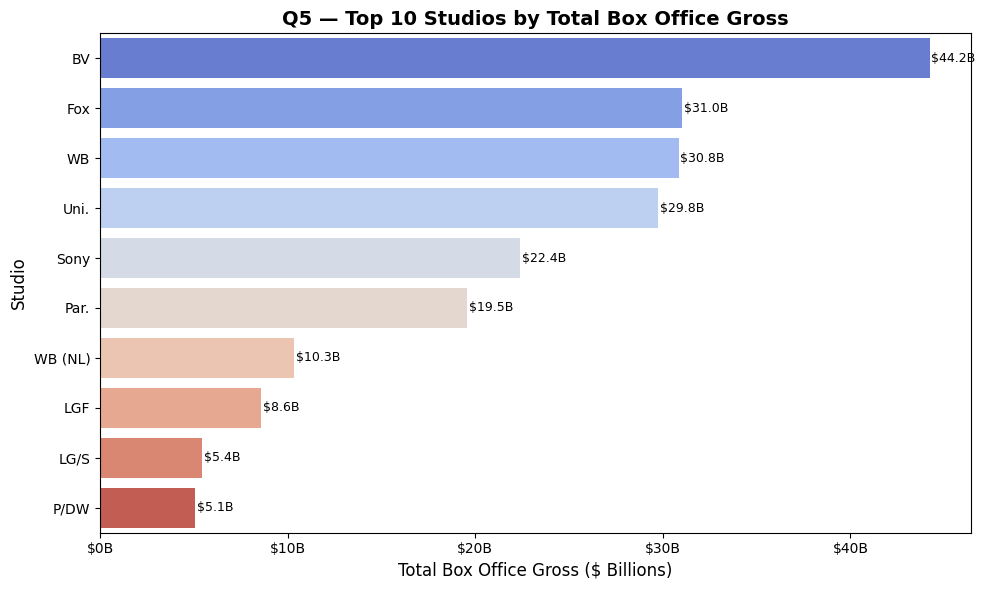

In [25]:
#Grouping by studio and sum total gross, then picking top 10
top_studios = (
    bom.groupby('studio')['total_gross']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Bar Plot
plt.figure(figsize=(10, 6))

ax = sns.barplot(data=top_studios,x='total_gross',y='studio',palette='coolwarm'
)

# Adding labels to bar values
labels = [f'${value/1e9:.1f}B' for value in top_studios['total_gross']]
for i, value in enumerate(top_studios['total_gross']):
    plt.text(value + 0.1e9, i, f'${value/1e9:.1f}B', va='center', fontsize=9)

plt.title('Q5 — Top 10 Studios by Total Box Office Gross', fontsize=14, fontweight='bold')
plt.xlabel('Total Box Office Gross ($ Billions)', fontsize=12)
plt.ylabel('Studio', fontsize=12)

# Formating x-axis to show billions instead of raw numbers
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e9:.0f}B'))

plt.tight_layout()
plt.savefig('../images/q5_Studios_total_gross.png')
plt.show()

### Conclusion

Buena Vista (Disney) leads all studios at 
13B ahead of second-placed Fox ($31.0B), showing it is highly dominant .

The top four studios including Buena Vista, Fox, Warner Bros, and Universal , all crossed $29B, while the remaining six studios earned significantly less, suggesting there is a clear gap between industry leaders and the rest of the studios

---

## Recommendations 

**Q1 Recommendation**

- Horror and Mystery are the safest starting genres for a studio with no track record. They require smaller budgets, carry lower financial risk, and have historically delivered strong returns

**Q2 Recommendation**

- The studio should target Blockbuster budgets (Over $100M) — they offer the strongest and most consistent returns
- Note:Blockbuster means a film with a very large production budget

**Q3 Recommendation**

- Release the first film in May or June, as these months have historically attracted the largest audiences and generated the highest box office returns. Additionally November is a reliable backup.

**Q4 Recommendation**

- Prioritize securing international distribution from the start, as the data shows the global market consistently delivers higher returns than the domestic market alone.

**Q5 Recommendation**

- Our company should model itself after Buena Vista and Universal, studying the genres they invest in, their budget ranges, and how they approach international distribution to build a winning strategy from the ground up.